In [87]:
# Import libries
import numpy as np
import pandas as pd
import os
import re
import glob
import json
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyranges as pr
import pysam
from matplotlib.patches import Patch

# from scipy.stats import mannwhitneyu, stats
# from statannotations.Annotator import Annotator

current_directory = os.getcwd()
print("Current Directory:", current_directory)
pd.set_option("display.max_columns", None)


Current Directory: /mnt/NAS3/home/jiwon/ECTRES/python


In [88]:
def classify_sample(row):
    if row['amplicon_decomposition_class'] == 'No amp/Invalid':
        return 'NoAmp'
    elif row['ecDNA+'] == 'Positive':
        return 'ecDNA'
    else:
        return 'ChrAmp'
        
    
def classify_amplicon(row):
    if row["ecDNA+"] == "Positive":
        return "ecDNA"
    if row["BFB+"] == "Positive":
        return "BFB"
    
    amp_class = row["amplicon_decomposition_class"]
    if amp_class == "Linear":
        return "Linear"
    if amp_class == "Complex-non-cyclic":
        return "Complex-non-cyclic"
    if amp_class == "No amp/Invalid":
        return "none"
    
    return "unknown"

## Manifest & sample barcoding

In [89]:
manifest=pd.read_csv('../manifest/ECTRES_clones_nf_dna_fastqs_20260303.csv')
manifest.head(2)

# manifest['aliquot_barcode'].nunique()

,aliquot_barcode,source_barcode,sample_barcode,patient_barcode,sample_type,tumor_or_normal,sequence_type,sample_legacy_id,gender,RGID,RGPL,RGPU,RGLB,RGDT,RGCN,FQ1,FQ2,action
0,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,ECGI1,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001,TP,tumor,WGS,EG_1,XY,2333V.6,ILLUMINA,2333VCLT4.6,ZKDN250032992,NaN,CBM,/mnt/NAS3/home/mary/rawData/ECTRES/X209SC25116...,/mnt/NAS3/home/mary/rawData/ECTRES/X209SC25116...,NaN
1,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,ECGI1,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001,TP,tumor,WGS,EG_1,XY,232NW.1,ILLUMINA,232NW2LT3.1,ZKDN250032992,NaN,CBM,/mnt/NAS3/home/mary/rawData/ECTRES/X209SC25116...,/mnt/NAS3/home/mary/rawData/ECTRES/X209SC25116...,NaN


In [90]:
manifest["sample_id"] = manifest["sample_legacy_id"].fillna("parental")
sample_mapping = manifest[['aliquot_barcode','source_barcode','sample_barcode','patient_barcode','sample_id']].drop_duplicates()

print(manifest.shape, sample_mapping.shape)

(87, 19) (77, 5)


In [91]:
sample_mapping.groupby('source_barcode').size()

source_barcode
ECGI1    34
EFM19    11
H2170    32
dtype: int64

In [92]:
sample_mapping.head()
# 

,aliquot_barcode,source_barcode,sample_barcode,patient_barcode,sample_id
0,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,ECGI1,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001,EG_1
2,ECTRES-ECGI1-0001-TPX-A10-WGS-3SW949,ECGI1,ECTRES-ECGI1-0001-TPX-A10,ECTRES-ECGI1-0001,EG_10
3,ECTRES-ECGI1-0001-TPX-A11-WGS-9HJ669,ECGI1,ECTRES-ECGI1-0001-TPX-A11,ECTRES-ECGI1-0001,EG_11
4,ECTRES-ECGI1-0001-TPX-A12-WGS-4SL389,ECGI1,ECTRES-ECGI1-0001-TPX-A12,ECTRES-ECGI1-0001,EG_12
5,ECTRES-ECGI1-0001-TPX-A13-WGS-3VZ640,ECGI1,ECTRES-ECGI1-0001-TPX-A13,ECTRES-ECGI1-0001,EG_13


## Amplicon Architect

In [93]:
base_dir = '../summary/aaSuite_germline_ms/10X'

In [94]:
!ls ../summary/aaSuite_germline_ms/10X/ 


ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_annotated_cycles_files.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_aa_amplicons.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_amplicon_classification_profiles.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_ecDNA_counts.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_feature_basic_properties.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_feature_entropy.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_gene_list.csv
log_20260313.txt


In [96]:
aa_classification=pd.read_csv(f'{base_dir}/ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_amplicon_classification_profiles.csv')

print(aa_classification.shape)
aa_classification.head(2)

(2425, 8)


,amplicon_barcode,aa_barcode,sample_name,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon10,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon10,No amp/Invalid,None detected,None detected,0
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon11,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon11,Linear,None detected,None detected,0


In [62]:
aa_classification.describe(include='object')

,amplicon_barcode,aa_barcode,sample_name,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+
count,2447,2447,2447,2447,2447,2447,2447
unique,2447,77,77,47,4,2,2
top,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon10,ECTRES-ECGI1-0001-TPX-A24-WGS-9KH851,ECTRES-ECGI1-0001-TPX-A24-WGS-9KH851,amplicon10,No amp/Invalid,None detected,None detected
freq,1,47,47,77,1432,2396,2378


In [97]:
aa_amplicons=pd.read_csv(f'{base_dir}/ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_aa_amplicons.csv')

print(aa_amplicons.shape)
# aa_amplicons.head()

(2425, 18)


In [98]:
aaSuite_gemline_ms_merge = pd.merge(aa_classification, aa_amplicons, how='inner', on=['amplicon_barcode', 'aa_barcode'])
aaSuite_gemline_ms_merge.shape

(2425, 24)

In [99]:
aaSuite_gemline_ms_merge['amplicon_decomposition_class'].unique()

array(['No amp/Invalid', 'Linear', 'Cyclic', 'Complex-non-cyclic'],
      dtype=object)

In [100]:
sample_mapping.columns

Index(['aliquot_barcode', 'source_barcode', 'sample_barcode',
       'patient_barcode', 'sample_id'],
      dtype='object')

In [101]:
sample_mapping['aa_barcode'] = sample_mapping['aliquot_barcode']

aaSuite_gemline_ms = pd.merge(aaSuite_gemline_ms_merge, sample_mapping[['aa_barcode','source_barcode','sample_id']], how='left', on=['aa_barcode'])

aaSuite_gemline_ms = aaSuite_gemline_ms.drop(columns=["sample_name"])

aaSuite_gemline_ms['amplicon_type'] = aaSuite_gemline_ms.apply(classify_amplicon, axis=1)

aaSuite_gemline_ms.head(2)


,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,amplicon_type
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon10,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon10,No amp/Invalid,None detected,None detected,0,10,amplicon10,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,15:20824661-20979641,",",154981,154980,2.750840,1,1,0,0,0,0,0,EFM19,EFM_5,none
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon11,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon11,Linear,None detected,None detected,0,11,amplicon11,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,16:33268118-33533123,",",265006,265003,3.730855,1,3,0,2,0,0,2,EFM19,EFM_5,Linear


In [102]:
# aaSuite_gemline_ms['source_barcode'].unique()

In [103]:
aaSuite_gemline_ms_ECGI=aaSuite_gemline_ms[(aaSuite_gemline_ms['source_barcode']=='EFM19')&(aaSuite_gemline_ms['sample_id']!='NCI_10')]
print(aaSuite_gemline_ms_ECGI.shape)
aaSuite_gemline_ms_ECGI.head(2)

(129, 26)


,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,amplicon_type
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon10,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon10,No amp/Invalid,None detected,None detected,0,10,amplicon10,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,15:20824661-20979641,",",154981,154980,2.750840,1,1,0,0,0,0,0,EFM19,EFM_5,none
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon11,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon11,Linear,None detected,None detected,0,11,amplicon11,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,16:33268118-33533123,",",265006,265003,3.730855,1,3,0,2,0,0,2,EFM19,EFM_5,Linear


In [104]:
# aaSuite_gemline_ms_ECGI.to_csv('../summary/aaSuite_germline_ms/1X/aaSuite_gemline_ms_ECGI.csv',index=False)


In [105]:
aaSuite_gemline_ms_ECGI.head(2)

,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,amplicon_type
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon10,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon10,No amp/Invalid,None detected,None detected,0,10,amplicon10,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,15:20824661-20979641,",",154981,154980,2.750840,1,1,0,0,0,0,0,EFM19,EFM_5,none
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon11,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon11,Linear,None detected,None detected,0,11,amplicon11,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,16:33268118-33533123,",",265006,265003,3.730855,1,3,0,2,0,0,2,EFM19,EFM_5,Linear


In [106]:
aaSuite_gemline_ms_ECGI[aaSuite_gemline_ms_ECGI['OncogenesAmplified'].str.contains(r'\bERBB2\b', na=False)]


,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,amplicon_type
12,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon8,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon8,Complex-non-cyclic,None detected,None detected,0,8,amplicon8,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,4,"12:31901506-33300002,13:20940908-20999226,17:3...","CD79B,ITGA3,MSI2,C17orf37,CSF3,HLF,ERBB2,BRIP1...",20936824,18682400,9.734101,3,60,14,38,13,1,26,EFM19,EFM_5,Complex-non-cyclic
25,ECTRES-EFM19-0001-TPX-A09-WGS-MS1ULC-amplicon8,ECTRES-EFM19-0001-TPX-A09-WGS-MS1ULC,amplicon8,Complex-non-cyclic,None detected,None detected,0,8,amplicon8,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,6,"12:59342-270363,12:31901506-33300002,13:209409...","ERBB2,NME1,SMARCE1,UBE2C,TBX2,CSF3,MSI2,AURKA,...",44596600,31352102,8.834054,4,98,19,64,13,0,51,EFM19,EFM_9,Complex-non-cyclic
29,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY-amplicon2,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY,amplicon2,Cyclic,Positive,None detected,5,2,amplicon2,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,9,"1:57048384-57838394,8:70156489-146364022,12:31...","C17orf37,RARA,SLC12A5,EIF3E,INTS2,NCOA2,TPD52,...",129515869,91115509,9.445070,6,257,56,153,35,7,126,EFM19,EFM_7,ecDNA
45,ECTRES-EFM19-0001-TPX-A04-WGS-BSX7Q9-amplicon6,ECTRES-EFM19-0001-TPX-A04-WGS-BSX7Q9,amplicon6,Complex-non-cyclic,None detected,None detected,0,6,amplicon6,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,6,"8:70156489-146364022,12:31901506-33300002,17:1...","SRSF6,NOV,MAFA,COX6C,NDRG1,BAALC,MLLT6,TNS4,EI...",124616054,77183748,10.852236,4,194,40,129,31,3,106,EFM19,EFM_4,Complex-non-cyclic
59,ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34-amplicon8,ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34,amplicon8,Cyclic,Positive,None detected,2,8,amplicon8,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,5,"12:31901506-33300002,13:20940993-20999141,17:1...","COL1A1,SRSF1,RPL23,DDX5,CSF3,SMARCE1,C17orf37,...",28336651,24191234,9.056473,3,73,18,42,14,1,28,EFM19,EFM_3,ecDNA
74,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K-amplicon9,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K,amplicon9,Complex-non-cyclic,None detected,None detected,0,9,amplicon9,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,4,"12:31901506-33300002,13:20998267-20999144,17:3...","RNF43,MSI2,TNS4,PPM1D,CLTC,ITGA3,THRA,CSF3,INT...",20879383,18667029,9.329692,3,65,14,42,13,1,31,EFM19,EFM_1,Complex-non-cyclic
78,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV-amplicon2,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV,amplicon2,Cyclic,Positive,None detected,3,2,amplicon2,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,9,"1:51679107-51890120,1:57048384-57918394,8:7015...","PTP4A3,PRDM14,DDX5,RECQL4,TNS4,MYC,NME1,EIF3E,...",129194129,92183100,9.745456,6,253,64,140,31,6,112,EFM19,EFM_11,ecDNA
88,ECTRES-EFM19-0001-TPX-A02-WGS-KVS1LG-amplicon2,ECTRES-EFM19-0001-TPX-A02-WGS-KVS1LG,amplicon2,Complex-non-cyclic,None detected,None detected,0,2,amplicon2,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,8,"1:57048384-57918394,8:70156489-146364022,12:31...","RUNX1T1,UBE2C,RARA,EEF1D,AURKA,EXT1,INTS8,BAAL...",129594841,89674828,9.592775,5,221,50,133,33,7,108,EFM19,EFM_2,Complex-non-cyclic
750,ECTRES-EFM19-0001-TPX-A06-WGS-JLY9G1-amplicon2,ECTRES-EFM19-0001-TPX-A06-WGS-JLY9G1,amplicon2,Cyclic,Positive,None detected,5,2,amplicon2,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,7,"1:57048384-57958394,8:70156489-146364022,12:31...","LAPTM4B,EIF3E,MYC,RPL23,CSF3,HLF,DDX5,PRDM14,R...",105454344,65770049,11.102215,5,203,43,129,35,5,108,EFM19,EFM_6,ecDNA
1390,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS-amplicon8,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS,amplicon8,Complex-non-cyclic,None detected,None det

In [107]:
# aaSuite_gemline_ms_ECGI[aaSuite_gemline_ms_ECGI['amplicon_type']=='ecDNA']

In [108]:
aaSuite_gemline_ms_ECGI["amplicon_type"].value_counts()

amplicon_type
none                  56
Linear                56
ecDNA                 10
Complex-non-cyclic     7
Name: count, dtype: int64

In [109]:
aaSuite_gemline_ms_ECGI[["ecDNA+", "BFB+", "amplicon_decomposition_class"]].drop_duplicates()
# ecDNA+	BFB+	amplicon_decomposition_class

# None detected	None detected	No amp/Invalid -> none
# None detected	None detected	Linear amplification -> Linear amplification
# None detected	Positive	Cyclic -> BFB
# None detected	Positive	Complex non-cyclic -> BFB
# None detected	None detected	Complex non-cyclic -> Complex non-cyclic
# Positive	None detected	Cyclic -> ecDNA
# None detected	Positive	Linear amplification -> BFB


,ecDNA+,BFB+,amplicon_decomposition_class
0,None detected,None detected,No amp/Invalid
1,None detected,None detected,Linear
6,Positive,None detected,Cyclic
12,None detected,None detected,Complex-non-cyclic


In [110]:
df=aaSuite_gemline_ms_ECGI.copy()


# df=df[df['sample_id']!='EG_21']
df.groupby(["sample_id", "amplicon_type"]).size().reset_index(name="count")

,sample_id,amplicon_type,count
0,EFM_1,Complex-non-cyclic,1
1,EFM_1,Linear,6
2,EFM_1,ecDNA,1
3,EFM_1,none,6
4,EFM_11,Linear,5
5,EFM_11,ecDNA,1
6,EFM_11,none,5
7,EFM_2,Complex-non-cyclic,1
8,EFM_2,Linear,4
9,EFM_2,none,5


In [111]:
table = (
    df.groupby(["sample_id", "amplicon_type"])
      .size()
      .unstack(fill_value=0)
)
# table

In [114]:
df['amplicon_type'].unique()

array(['none', 'Linear', 'ecDNA', 'Complex-non-cyclic'], dtype=object)

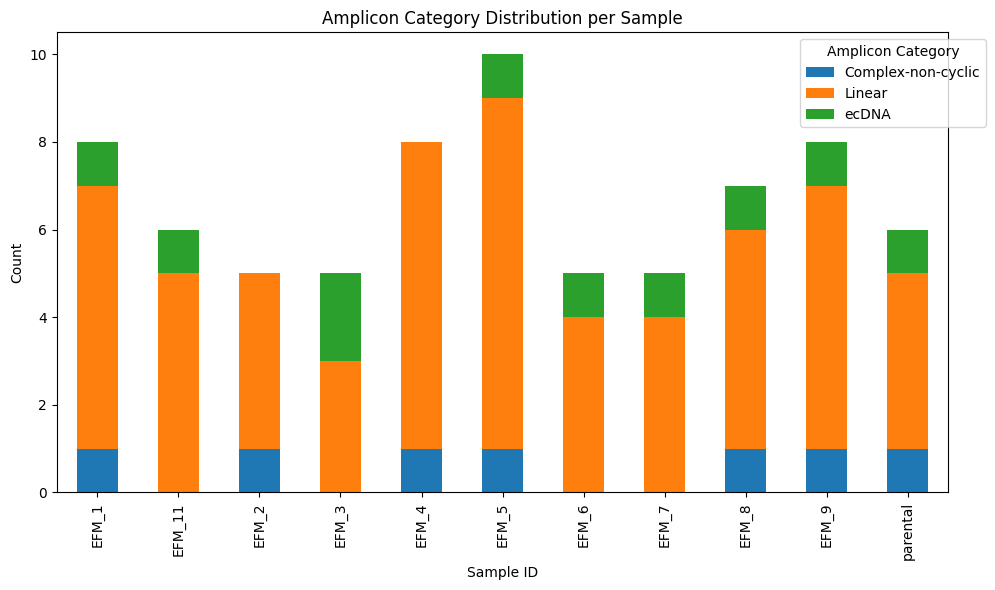

In [112]:
# table.plot(
#     kind="bar",
#     stacked=True,
#     figsize=(10,6)
# )

table_no_none = table.drop(columns=["none"], errors="ignore")
table_no_none.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.ylabel("Count")
plt.xlabel("Sample ID")
plt.title("Amplicon Category Distribution per Sample")
plt.legend(title="Amplicon Category", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

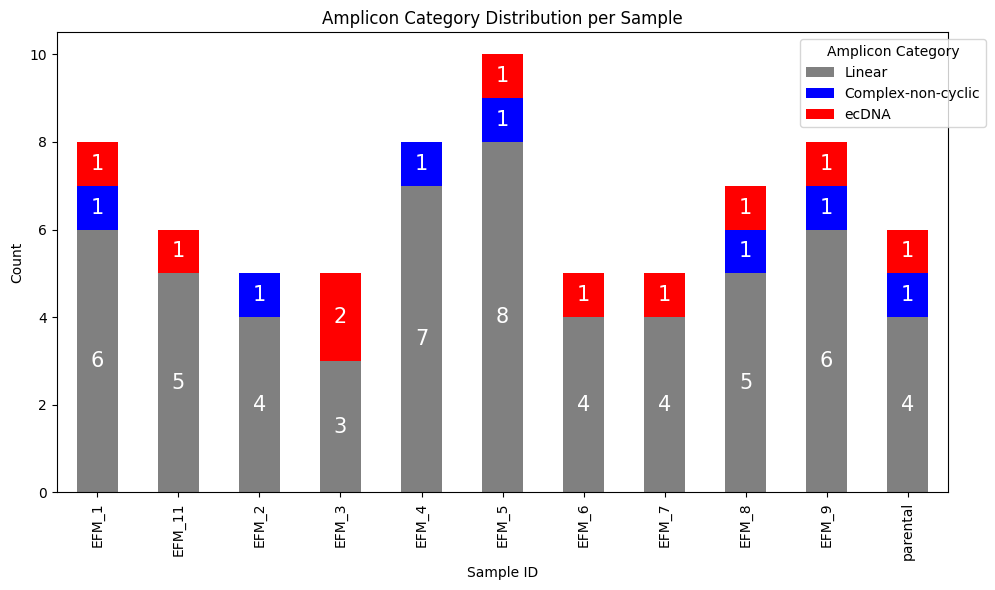

In [118]:
import matplotlib.pyplot as plt

# none 제외
table_no_none = table.drop(columns=["none"], errors="ignore").copy()

# 표시 순서 고정
desired_order = ["Linear", "BFB", "Complex-non-cyclic", "ecDNA"]
existing_cols = [c for c in desired_order if c in table_no_none.columns]
table_no_none = table_no_none[existing_cols]

# 원하는 색 지정
color_map = {
    "ecDNA": "red",
    "Complex-non-cyclic": "blue",
    "BFB": "green",
    "Linear": "gray"
}
colors = [color_map[col] for col in table_no_none.columns]

# plot
ax = table_no_none.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=colors
)

# 각 bar segment 안에 숫자 넣기
for patch in ax.patches:
    height = patch.get_height()
    if height > 0:
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_y() + height / 2
        ax.text(
            x, y, f"{int(height)}",
            ha="center", va="center",
            fontsize=15, color="white"
        )

plt.ylabel("Count")
plt.xlabel("Sample ID")
plt.title("Amplicon Category Distribution per Sample")
plt.legend(title="Amplicon Category", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [78]:
# df[df['amplicon_type']=='ecDNA']

In [79]:
# A. Parental Structure-calss retention: same clasee, switched class, not detected
# B. parental interval retention: yes, partial, no
# C. parental oncogene retention: retained, lost, uncertain


In [80]:
# df[df['OncogenesAmplified'].str.contains(r'\bERBB2\b', na=False)]
df.head(2)

,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,amplicon_type
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon10,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon10,No amp/Invalid,None detected,None detected,0,10,amplicon10,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,15:20824661-20979641,",",154981,154980,2.750840,1,1,0,0,0,0,0,EFM19,EFM_5,none
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon11,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon11,Linear,None detected,None detected,0,11,amplicon11,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,16:33268118-33533123,",",265006,265003,3.730855,1,3,0,2,0,0,2,EFM19,EFM_5,Linear


In [119]:
# OncogenesAmplified 컬럼의 쉼표로 구분된 유전자들을 explode
# 1. 먼저 쉼표(,)로 split → 리스트로 변환
df['OncogenesAmplified_split'] = df['OncogenesAmplified'].str.split(',')

# 2. explode를 통해 유전자별로 row 늘리기
df_exploded = df.explode('OncogenesAmplified_split')

# 3. 양끝 공백 제거 및 빈 문자열 제거
df_exploded['OncogenesAmplified_split'] = df_exploded['OncogenesAmplified_split'].str.strip()
df_exploded = df_exploded[df_exploded['OncogenesAmplified_split'] != '']

# 4. 컬럼명 정리
df_exploded = df_exploded.rename(columns={'OncogenesAmplified_split': 'Oncogene'})

# 결과 확인
print(df.shape,df_exploded.shape)
df_exploded.head()

(129, 27) (846, 27)


,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,amplicon_type,Oncogene
2,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon12,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon12,No amp/Invalid,None detected,None detected,0,12,amplicon12,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,17:9386618-10131619,"GAS7,",745002,745001,3.458185,1,1,0,0,0,0,0,EFM19,EFM_5,none,GAS7
3,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon13,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon13,Linear,None detected,None detected,0,13,amplicon13,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,17:11616616-19016612,"SREBF1,COPS3,MAP2K4,",7399997,5845391,7.183853,1,7,0,6,1,0,6,EFM19,EFM_5,Linear,SREBF1
3,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon13,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon13,Linear,None detected,None detected,0,13,amplicon13,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,17:11616616-19016612,"SREBF1,COPS3,MAP2K4,",7399997,5845391,7.183853,1,7,0,6,1,0,6,EFM19,EFM_5,Linear,COPS3
3,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon13,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon13,Linear,None detected,None detected,0,13,amplicon13,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,17:11616616-19016612,"SREBF1,COPS3,MAP2K4,",7399997,5845391,7.183853,1,7,0,6,1,0,6,EFM19,EFM_5,Linear,MAP2K4
4,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon14,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon14,Linear,None detected,None detected,0,14,amplicon14,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,20:39676747-63025520,"AURKA,SALL4,SDC4,RAB22A,SS18L1,ZNF217,EEF1A2,S...",23348774,12794676,7.026961,1,32,4,23,0,0,23,EFM19,EFM_5,Linear,AURKA


## AA gene list

In [120]:
sample_mapping.head(2)

,aliquot_barcode,source_barcode,sample_barcode,patient_barcode,sample_id,aa_barcode
0,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,ECGI1,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001,EG_1,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349
2,ECTRES-ECGI1-0001-TPX-A10-WGS-3SW949,ECGI1,ECTRES-ECGI1-0001-TPX-A10,ECTRES-ECGI1-0001,EG_10,ECTRES-ECGI1-0001-TPX-A10-WGS-3SW949


In [121]:
# gene_list=pd.read_csv(f'{base_dir}/scratch-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000--1X_20260303_combined_gene_list.csv')
# gene_list = pd.merge(gene_list, sample_mapping[['aa_barcode','sample_id','source_barcode']], how='left', on=['aa_barcode'])
# gene_list_ECGI=gene_list[gene_list["source_barcode"]=='ECGI1']
# gene_list_ECGI["amplicon_CAT"] = gene_list_ECGI["feature"].str.extract(r"^(.*?)_")
# print(gene_list.shape)  #(16750, 9)
# gene_list.head(1)

In [122]:
gene_list_ECGI[(gene_list_ECGI['sample_id']=='parental')&(gene_list_ECGI['gene']=='ERBB2')]

NameError: name 'gene_list_ECGI' is not defined

In [123]:
df_exploded['amplicon_type'].unique()

array(['none', 'Linear', 'ecDNA', 'Complex-non-cyclic'], dtype=object)

In [128]:
sample_order = (
    df_exploded["sample_id"]
    .unique()
)

sample_order = sorted(
    sample_order,
    key=lambda x: (x != "parental", x)
)

cn_matrix = df_exploded.pivot(
    index="Oncogene",
    columns="sample_id",
    values="AverageAmplifiedCopyCount"
).reindex(columns=sample_order)

cat_matrix = df_exploded.pivot(
    index="Oncogene",
    columns="sample_id",
    values="amplicon_type"
).reindex(columns=sample_order)

color_map = {
    "ecDNA": "red",                 # red
    "BFB": "green",                   # orange
    "Linear": "gray",  # blue
    "Complex-non-cyclic": "blue",    # green
    "none": "white"                # gray
}

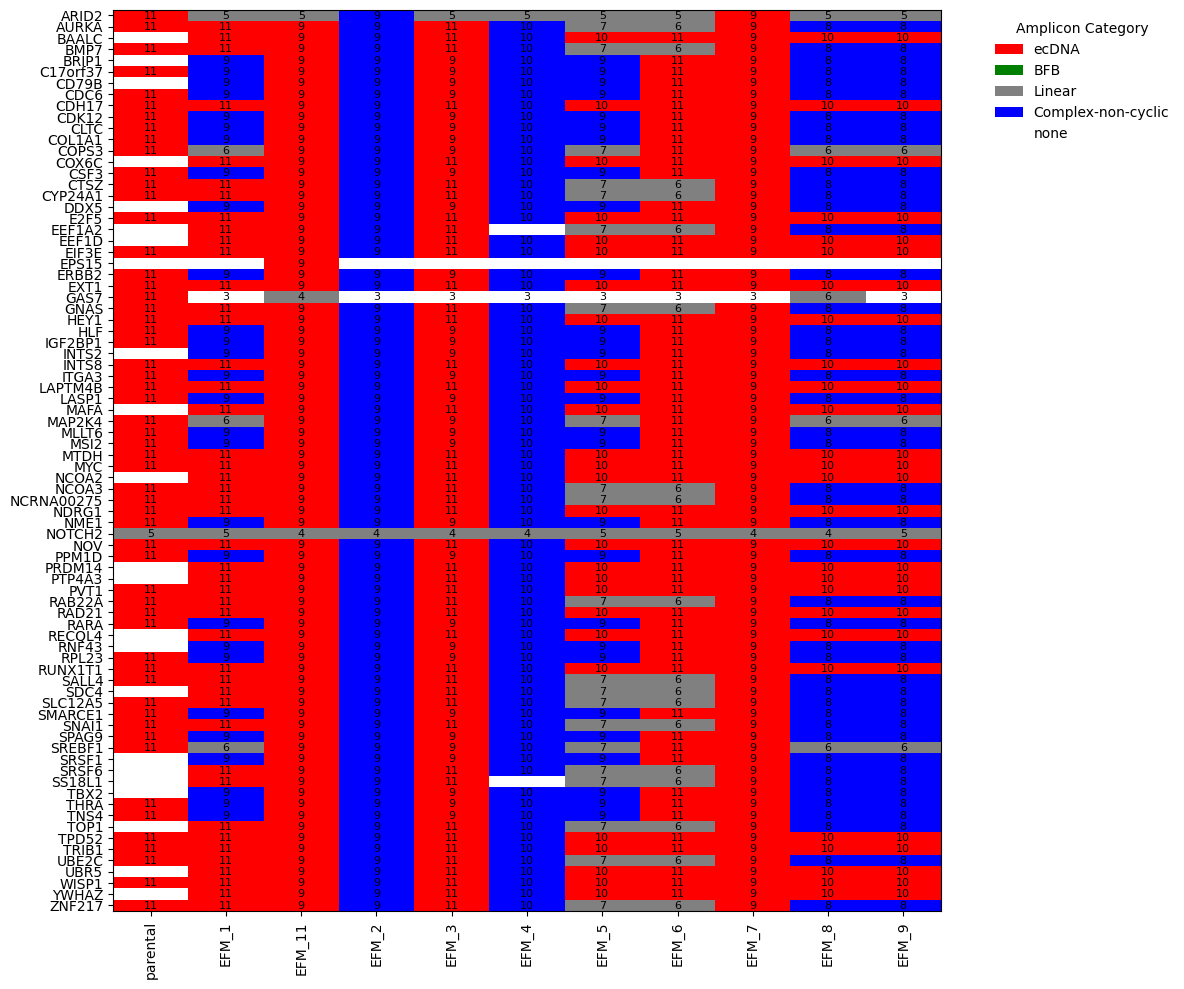

In [129]:
fig, ax = plt.subplots(figsize=(12, 10))

n_genes = cn_matrix.shape[0]
n_samples = cn_matrix.shape[1]

for i in range(n_genes):
    for j in range(n_samples):
        
        category = cat_matrix.iloc[i, j]
        value = cn_matrix.iloc[i, j]
        
        color = color_map.get(category, "white")
        
        # 사각형 그리기
        rect = plt.Rectangle((j, i), 1, 1, facecolor=color)
        ax.add_patch(rect)
        
        # CN 숫자 annotation
        if not pd.isna(value):
            ax.text(
                j + 0.5,
                i + 0.5,
                int(value),
                ha="center",
                va="center",
                fontsize=8,
                color="black"
            )

ax.set_xlim(0, n_samples)
ax.set_ylim(0, n_genes)

ax.set_xticks(np.arange(n_samples) + 0.5)
ax.set_xticklabels(cn_matrix.columns, rotation=90)

ax.set_yticks(np.arange(n_genes) + 0.5)
ax.set_yticklabels(cn_matrix.index)

legend_elements = [
    Patch(facecolor=color, label=label)
    for label, color in color_map.items()
]

ax.legend(
    handles=legend_elements,
    title="Amplicon Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False
)


ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [126]:
# cn_raw

In [140]:
sample_category = (
    gene_list_ECGI
    .groupby(["sample_id", "amplicon_CAT"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .drop_duplicates("sample_id")
    .set_index("sample_id")["amplicon_CAT"]
)

NameError: name 'gene_list_ECGI' is not defined

In [141]:
col_colors = sample_category.map(color_map)

cn_raw = cn_matrix.fillna(0)

cn_raw.head()

col_var = cn_raw.var(axis=0)
cn_raw = cn_raw.loc[:, col_var > 0]

# col_colors도 동일하게 맞춰줘야 함
col_colors = col_colors.loc[cn_raw.columns]

row_var = cn_raw.var(axis=1)
cn_raw = cn_raw.loc[row_var > 0, :]
g = sns.clustermap(
    cn_raw,
    metric="correlation",
    method="average",
    cmap="viridis",
    col_colors=col_colors,
    figsize=(12, 10),
    col_cluster=True,
    row_cluster=True
)

plt.show()

NameError: name 'sample_category' is not defined

### Clustering

In [142]:
df_onehot.head(2)

,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,Oncogene,amplicon_type_Complex-non-cyclic,amplicon_type_Linear,amplicon_type_ecDNA,amplicon_type_none
2,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon12,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon12,No amp/Invalid,None detected,None detected,0,12,amplicon12,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,17:9386618-10131619,"GAS7,",745002,745001,3.458185,1,1,0,0,0,0,0,EFM19,EFM_5,GAS7,False,False,False,True
3,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon13,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon13,Linear,None detected,None detected,0,13,amplicon13,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,17:11616616-19016612,"SREBF1,COPS3,MAP2K4,",7399997,5845391,7.183853,1,7,0,6,1,0,6,EFM19,EFM_5,SREBF1,False,True,False,False


In [143]:
df_onehot = pd.get_dummies(
    df_exploded,
    columns=["amplicon_type"]
)

# print(df_onehot.head())

feature_matrix = pd.pivot_table(
    df_onehot,
    index="Oncogene",
    columns="sample_id",
    values=["AverageAmplifiedCopyCount",
            "amplicon_type_ecDNA",
            "amplicon_type_BFB",
            "amplicon_type_Linear",
            "amplicon_type_Complex-non-cyclic",
            "amplicon_type_none"],
    aggfunc="max"
)

feature_matrix = pd.pivot_table(
    df_onehot,
    index="Oncogene",
    columns="sample_id",
    values=["AverageAmplifiedCopyCount",
            "amplicon_type_ecDNA",
            "amplicon_type_BFB",
            "amplicon_type_Linear",
            "amplicon_type_Complex-non-cyclic",
            "amplicon_type_none"],
    aggfunc="max"
)

# feature_matrix.head()

KeyError: 'amplicon_type_BFB'

In [144]:
feature_matrix.columns = [
    f"{feature}_{sample}"
    for feature, sample in feature_matrix.columns
]

ValueError: too many values to unpack (expected 2)

In [145]:
clone_feature = feature_matrix.T
# clone_feature.head()

In [146]:
# CN magnitude와 type을 곱해 하나의 구조-가중 CN으로 만들 수도 있습니다.
df_exploded["weighted_cn"] = (
    df_exploded["AverageAmplifiedCopyCount"] *
    df_exploded["amplicon_type"].map({
        "ecDNA": 5,
        "BFB": 3,
        "Linear amplification": 1,
        "Complex non-cyclic": 2,
        "none": 0
    })
)

cn_weighted = pd.pivot_table(
    df_exploded,
    index="sample_id",
    columns="Oncogene",
    values="weighted_cn",
    aggfunc="max"
).fillna(0)

In [147]:
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist

distance_matrix = pdist(cn_weighted, metric="euclidean")
# distance_matrix = pdist(cn_weighted, metric="correlation")

Z = linkage(distance_matrix, method="average")
# Z

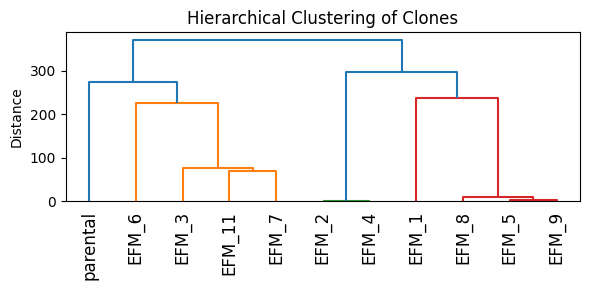

In [148]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(6, 3))

dendrogram(
    Z,
    labels=cn_weighted.index,
    leaf_rotation=90
)

plt.title("Hierarchical Clustering of Clones")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

(10, 79)


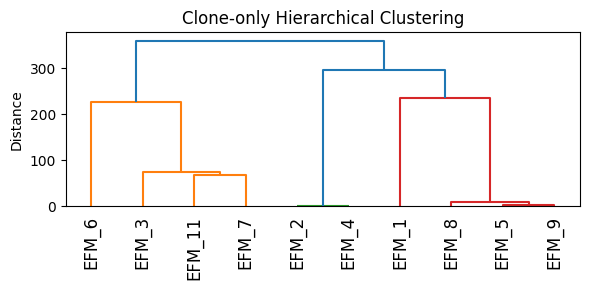

In [149]:
### cluster within clones (elminate parental)
cn_clone = cn_weighted.drop(index="parental", errors="ignore")
print(cn_clone.shape)
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist

distance_matrix = pdist(cn_clone, metric="euclidean")
Z_clone = linkage(distance_matrix, method="average")


plt.figure(figsize=(6, 3))
dendrogram(
    Z_clone,
    labels=cn_clone.index,
    leaf_rotation=90
)
plt.title("Clone-only Hierarchical Clustering")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [150]:
from scipy.cluster.hierarchy import fcluster

# cluster_labels = fcluster(Z_clone, t=5, criterion="maxclust")
cluster_labels = fcluster(Z_clone, t=1000, criterion="distance")
cluster_labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [151]:
ddata = dendrogram(
    Z_clone,
    labels=cn_clone.index
)

leaf_order = ddata["ivl"]
print(leaf_order)

['EFM_6', 'EFM_3', 'EFM_11', 'EFM_7', 'EFM_2', 'EFM_4', 'EFM_1', 'EFM_8', 'EFM_5', 'EFM_9']


In [163]:
## manually grouping 
cluster_map = {}

for s in leaf_order[0:4]:
    cluster_map[s] = 3
for s in leaf_order[4:6]:
    cluster_map[s] = 2
for s in leaf_order[6:]:
    cluster_map[s] = 1

    
cluster_df = pd.DataFrame({
    "sample_id": list(cluster_map.keys()),
    "cluster_group": list(cluster_map.values())
})
# 
cluster_df

,sample_id,cluster_group
0,EFM_6,3
1,EFM_3,3
2,EFM_11,3
3,EFM_7,3
4,EFM_2,2
5,EFM_4,2
6,EFM_1,1
7,EFM_8,1
8,EFM_5,1
9,EFM_9,1


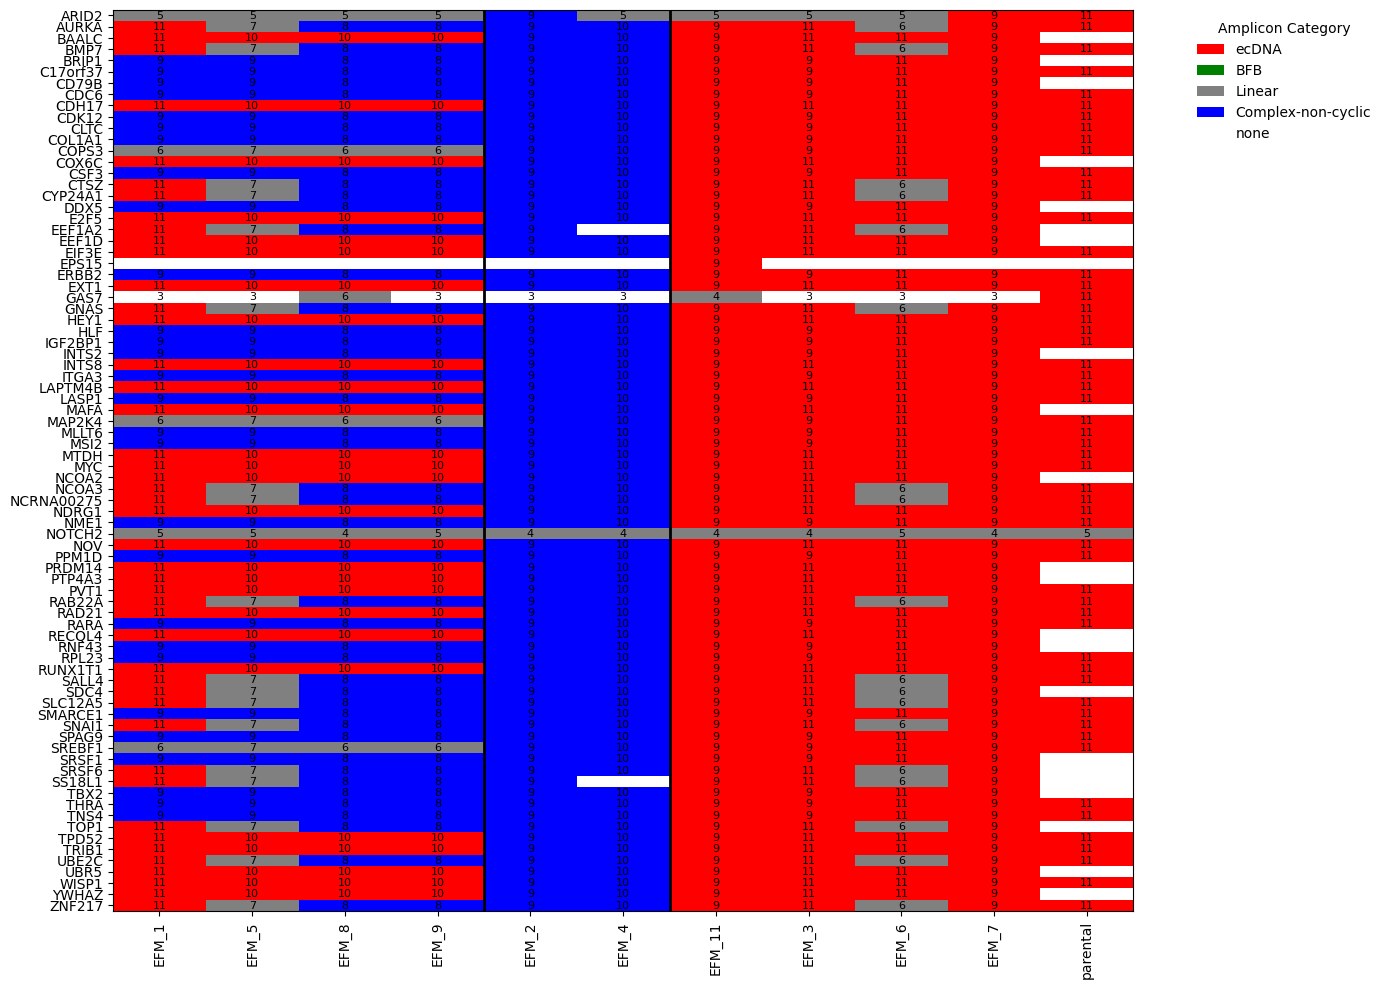

In [164]:
# =========================
# 1️⃣ Sample order by cluster
# =========================

ordered_samples = (
    cluster_df
    .sort_values(["cluster_group", "sample_id"])
    ["sample_id"]
    .tolist()
)

# parental이 matrix에 존재하면 추가
if "parental" in cn_matrix.columns:
    ordered_samples = ordered_samples + ["parental"]
else:
    ordered_samples = ordered_samples
    
# matrix reorder
cn_matrix = cn_matrix[ordered_samples]
cat_matrix = cat_matrix[ordered_samples]

# =========================
# 2️⃣ Cluster boundary 계산
# =========================

cluster_sizes = (
    cluster_df
    .sort_values(["cluster_group", "sample_id"])
    .groupby("cluster_group")
    .size()
)

boundaries = np.cumsum(cluster_sizes.values)

# =========================
# 3️⃣ Heatmap 그리기
# =========================

fig, ax = plt.subplots(figsize=(14, 10))

n_genes = cn_matrix.shape[0]
n_samples = cn_matrix.shape[1]

for i in range(n_genes):
    for j in range(n_samples):
        
        category = cat_matrix.iloc[i, j]
        value = cn_matrix.iloc[i, j]
        
        color = color_map.get(category, "white")
        
        # cell rectangle
        rect = plt.Rectangle((j, i), 1, 1, facecolor=color)
        ax.add_patch(rect)
        
        # CN annotation
        if not pd.isna(value):
            ax.text(
                j + 0.5,
                i + 0.5,
                int(value),
                ha="center",
                va="center",
                fontsize=8,
                color="black"
            )

# axis 설정
ax.set_xlim(0, n_samples)
ax.set_ylim(0, n_genes)

ax.set_xticks(np.arange(n_samples) + 0.5)
ax.set_xticklabels(cn_matrix.columns, rotation=90)

ax.set_yticks(np.arange(n_genes) + 0.5)
ax.set_yticklabels(cn_matrix.index)

# cluster 경계선
for b in boundaries[:-1]:
    ax.axvline(b, color="black", linewidth=2)

# legend
legend_elements = [
    Patch(facecolor=color, label=label)
    for label, color in color_map.items()
]

ax.legend(
    handles=legend_elements,
    title="Amplicon Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False
)

ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [154]:
cn_matrix.columns


Index(['EFM_11', 'EFM_3', 'EFM_6', 'EFM_7', 'EFM_2', 'EFM_4', 'EFM_1', 'EFM_5',
       'EFM_8', 'EFM_9', 'parental'],
      dtype='object', name='sample_id')

In [155]:
# ecDNA는:uneven segregation/dynamic copy number change/structural instability
# => single-cell 유래 clone도 내부적으로 구조가 계속 변함
# clone ≠ genetically uniform population

# ✔ Oncogene CN
# ✔ Amplicon type
# ✔ PURPLE segment CN
# ✔ Amplicon complexity score
# ✔ ERBB2 locus SV or mutation

# "resistance mechanism이 다를 가능성이 높은 clone"을 분리???


## structural retention analysis

1) interval 
2) Junction
3) structure transform

Observation: Parental ecDNA는 많은데 clone에서 ecDNA call이 감소
QC/Validation: 기술적 bias 여부 점검
Structural retention: interval/junction 기반으로 “진짜 소실 vs 형태전환” 판정
Architecture-aware clustering: oncogene CN + amplicon type 기반 clone grouping(heatmap)
Experiment plan: cluster별 대표 clone 선택 → therapy 투여 → resistance trajectory 비교
Next features: segment CN/complexity/SV(ERBB2 locus)/driver mutation 추가로 “mechanism-oriented stratification” 확장 제안

In [156]:
aa_cycles=pd.read_csv(f'{base_dir}/scratch-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000--1X_20260303_annotated_cycles_files.csv')
# (3626, 11)

aa_cycles=pd.merge(aa_cycles, aaSuite_gemline_ms[['aa_barcode','amplicon_index','source_barcode','sample_id','amplicon_type']], how='left', on=['aa_barcode','amplicon_index'])
print(aa_cycles.shape) #(3626, 14)


aa_cycles_ECGI = aa_cycles[(aa_cycles['source_barcode']=='ECGI1')&(aa_cycles['sample_id']!='EG_21')]

print(aa_cycles_ECGI.shape) #(2901, 14)

aa_cycles_ECGI.head(2)




FileNotFoundError: [Errno 2] No such file or directory: '../summary/aaSuite_germline_ms/10X/scratch-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000--1X_20260303_annotated_cycles_files.csv'

In [157]:
# ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985

aa_cycles_ECGI[(aa_cycles_ECGI['aa_barcode']=='ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985')&(aa_cycles_ECGI['amplicon_index']=='amplicon8')]

NameError: name 'aa_cycles_ECGI' is not defined

In [158]:
# table = (
# aa_cycles.groupby(["aa_barcode", "cycle_index"]).size().unstack(fill_value=0)
# )
# table

In [159]:
aa_cycles_ECGI['CycleClass'].unique()
df['CycleClass'].unique()

NameError: name 'aa_cycles_ECGI' is not defined

In [160]:
# OncogenesAmplified 컬럼의 쉼표로 구분된 유전자들을 explode
# 1. 먼저 쉼표(,)로 split → 리스트로 변환
df = aa_cycles_ECGI.copy()
df = df[df['CycleClass']!='Invalid']
# df = df[(df['CycleClass'].isin(['ecDNA-like','BFB-like']))&(df['sample_id']=='parental')]
df['Intervals_split'] = df['Intervals'].str.split(',')

# 2. explode를 통해 유전자별로 row 늘리기
df_exploded = df.explode('Intervals_split')

# 3. 양끝 공백 제거 및 빈 문자열 제거
df_exploded['Intervals_split'] = df_exploded['Intervals_split'].str.strip()
df_exploded = df_exploded[df_exploded['Intervals_split'] != '']

# 4. 컬럼명 정리
# df_exploded = df_exploded.rename(columns={'OncogenesAmplified_split': 'Oncogene'})
print(df_exploded.shape, df.shape)
# 결과 확인
df_exploded

NameError: name 'aa_cycles_ECGI' is not defined

In [161]:
df_exploded_all=df_exploded.copy()

In [162]:
df_exploded['IsCyclicPath'].unique()
df_exploded['CycleClass'].unique()
# array(['Invalid', 'Linear', 'Rearranged', 'BFB-like', 'BFB-like_Invalid',
#        'ecDNA-like'], dtype=object)

df_exploded.columns

df_exploded[['file_name', 'aa_barcode', 'amplicon_index', 'cycle_index',]]

KeyError: 'IsCyclicPath'

In [97]:
# 중복된 행 확인 (디버깅용)
duplicates = df_exploded[df_exploded.duplicated(subset=["Intervals_split", "sample_id"])]
print(f"중복된 행 개수: {len(duplicates)}")
# duplicates

중복된 행 개수: 12


In [98]:
interval_list=df_exploded[df_exploded['CycleClass']=='ecDNA-like']['Intervals_split'].unique().tolist()
interval_list

# df_exploded

['8:133740027-136798512',
 '8:133742514-136795218',
 '1:1199386-2120873',
 '1:1199945-2119874',
 '14:24195081-29617680',
 '16:70152088-70233382',
 '16:74396970-74430026',
 '1:153363250-153407852',
 '1:153408630-153418801',
 '1:160244494-160670989',
 '11:15088861-15089052',
 '1:160671040-161054710']

In [99]:
df_exploded['CycleClass'].unique()

array(['Rearranged', 'Linear', 'BFB-like', 'BFB-like_Invalid',
       'ecDNA-like'], dtype=object)

In [100]:
# df_exploded[(df_exploded['sample_id']=='parental')&(df_exploded['amplicon_type']=='ecDNA')]['amplicon_index'].unique()

# interval_list=df_exploded[(df_exploded['sample_id']=='parental')&(df_exploded['amplicon_type'].isin(['ecDNA','BFB-like']))]['Intervals_split'].unique().tolist()
interval_list=df_exploded[(df_exploded['amplicon_type'].isin(['ecDNA','BFB']))]['Intervals_split'].unique().tolist()
interval_list
len(interval_list)
# df_exploded

314

In [101]:
df_exploded.head(2)

,file_name,aa_barcode,amplicon_index,cycle_index,cycle_barcode,Copy_count,Length,IsCyclicPath,CycleClass,Segments,Intervals,source_barcode,sample_id,amplicon_type,Intervals_split
264,ECTRES-ECGI1-0001-TPX-A26-WGS-6JQ388_amplicon1...,ECTRES-ECGI1-0001-TPX-A26-WGS-6JQ388,amplicon11,cycle1,ECTRES-ECGI1-0001-TPX-A26-WGS-6JQ388_amplicon1...,2.525651,562106,False,Rearranged,"0+,1+,3-,0+\n","5:56660725-56987192,5:56750400-56986037",ECGI1,EG_26,Linear,5:56660725-56987192
264,ECTRES-ECGI1-0001-TPX-A26-WGS-6JQ388_amplicon1...,ECTRES-ECGI1-0001-TPX-A26-WGS-6JQ388,amplicon11,cycle1,ECTRES-ECGI1-0001-TPX-A26-WGS-6JQ388_amplicon1...,2.525651,562106,False,Rearranged,"0+,1+,3-,0+\n","5:56660725-56987192,5:56750400-56986037",ECGI1,EG_26,Linear,5:56750400-56986037


In [102]:
df_exploded['CycleClass'].unique()


array(['Rearranged', 'Linear', 'BFB-like', 'BFB-like_Invalid',
       'ecDNA-like'], dtype=object)

In [103]:
color_map2 = {
    "ecDNA-like": "#d62728",                 # red
    "BFB-like": "#ff7f0e",                   # orange
    "BFB-like_Invalid": "#ff7f0e",                   # orange
    "Linear": "#1f77b4",  # blue
    "Rearranged": "#2ca02c",    # green
    "Invalid": "#7f7f7f"                # gray
}

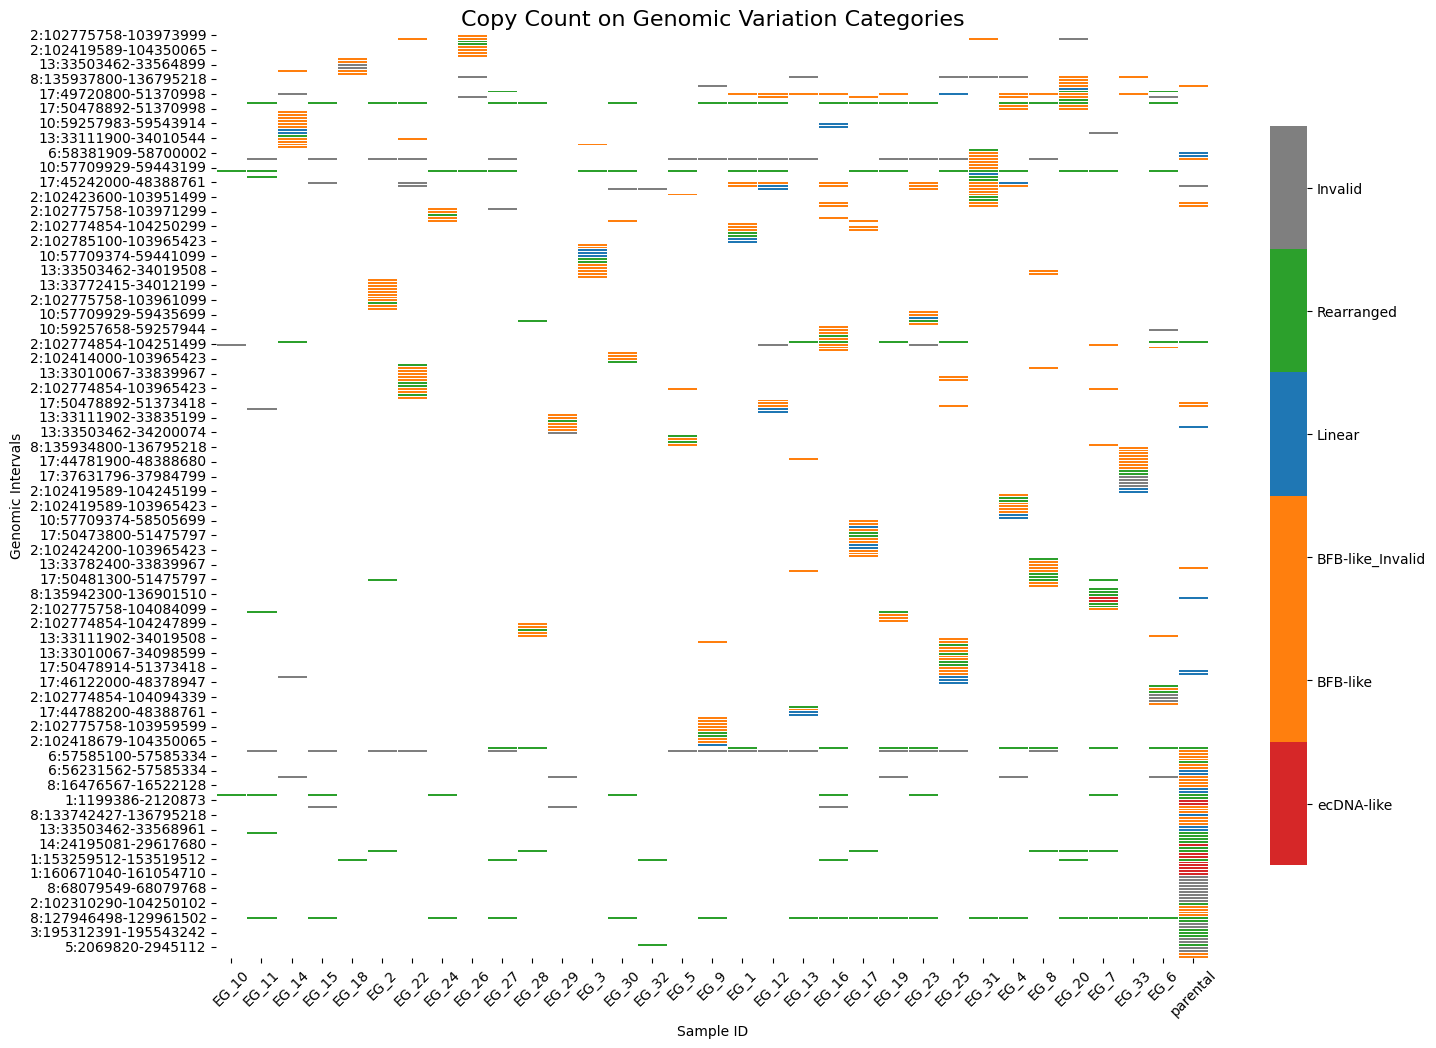

In [104]:
from matplotlib.colors import ListedColormap

# df_exploded = df_exploded_all.copy()

df_exploded = df_exploded_all[df_exploded_all['Intervals_split'].isin(interval_list)]

# 2. 피벗 테이블 생성 (기존 코드 유지)
cn_matrix = df_exploded.pivot_table(
    index="Intervals_split",
    columns="sample_id",
    values="Copy_count",
    aggfunc='max'
).reindex(columns=ordered_samples)

cat_matrix = df_exploded.pivot_table(
    index="Intervals_split",
    columns="sample_id",
    values="CycleClass",
    aggfunc=lambda x: x.iloc[0]
).reindex(columns=ordered_samples)


# 1. 'ecDNA-like'를 포함한 인터벌 필터링
# ecdna_intervals = cat_matrix.index[cat_matrix.isin(["ecDNA-like"]).any(axis=1)]

# 필터링된 데이터 생성
# cn_matrix_filtered = cn_matrix.loc[ecdna_intervals]
# cat_matrix_filtered = cat_matrix.loc[ecdna_intervals]
cn_matrix_filtered = cn_matrix.loc[interval_list]
cat_matrix_filtered = cat_matrix.loc[interval_list]

# 2. 카테고리(문자열)를 숫자로 매핑 (컬러맵 적용용)
category_labels = list(color_map2.keys())
category_to_int = {label: i for i, label in enumerate(category_labels)}
int_to_color = [color_map2[label] for label in category_labels]

# 히트맵 배경용 숫자 행렬
cat_numeric = cat_matrix_filtered.replace(category_to_int)

# 3. 히트맵 그리기
plt.figure(figsize=(16, 12))  # 숫자가 잘 보이도록 사이즈를 넉넉히 조절

custom_cmap = ListedColormap(int_to_color)

# annot=cn_matrix_filtered: 실제 Copy Count 숫자를 셀에 표시
# fmt=".1f": 소수점 첫째자리까지 표시 (정수라면 "d"로 변경)
ax = sns.heatmap(
    cat_numeric, 
#     annot=cn_matrix_filtered, 
#     fmt=".1f", 
    cmap=custom_cmap, 
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.8}
)

# 4. 컬러바 범례 설정 (오른쪽 바에 카테고리명 표시)
colorbar = ax.collections[0].colorbar
num_labels = len(category_labels)
r = colorbar.vmax - colorbar.vmin
colorbar.set_ticks([colorbar.vmin + r / num_labels * (i + 0.5) for i in range(num_labels)])
colorbar.set_ticklabels(category_labels)

plt.title("Copy Count on Genomic Variation Categories", fontsize=16)
plt.ylabel("Genomic Intervals")
plt.xlabel("Sample ID")
plt.xticks(rotation=45)
plt.show()

In [105]:
def parse_interval(s: str):
    """
    Returns: (chrom, start, end)
    Supports: chr17:123-456, 17:123-456, chr17_123_456, 17_123_456, chr17-123-456 ...
    """
    s = str(s)

    # 공통: chr 제거, 구분자 통일
    s2 = s.replace("CHR", "chr").replace("Chr", "chr")
    s2 = s2.replace("chr", "")
    s2 = re.sub(r"[,\s]", "", s2)  # comma/space 제거

    # 패턴들 시도
    patterns = [
        r"^(?P<chrom>[0-9XYM]+)[:](?P<start>\d+)[-](?P<end>\d+)$",     # 17:123-456
        r"^(?P<chrom>[0-9XYM]+)[_](?P<start>\d+)[_](?P<end>\d+)$",     # 17_123_456
        r"^(?P<chrom>[0-9XYM]+)[-](?P<start>\d+)[-](?P<end>\d+)$",     # 17-123-456
        r"^(?P<chrom>[0-9XYM]+)[:](?P<start>\d+)$",                    # 17:123 (end 없음)
        r"^(?P<chrom>[0-9XYM]+)[_](?P<start>\d+)$",                    # 17_123 (end 없음)
    ]

    chrom = start = end = np.nan
    for pat in patterns:
        m = re.match(pat, s2)
        if m:
            chrom = m.group("chrom")
            start = int(m.group("start"))
            end = int(m.group("end")) if "end" in m.groupdict() and m.group("end") else np.nan
            break

    return chrom, start, end

def chrom_to_order(chrom):
    """chr 자연 정렬: 1..22, X=23, Y=24, M/MT=25"""
    if pd.isna(chrom):
        return 1_000  # 파싱 실패한 것들은 맨 뒤
    c = str(chrom).upper()
    if c in ["X"]:
        return 23
    if c in ["Y"]:
        return 24
    if c in ["M", "MT"]:
        return 25
    try:
        return int(c)
    except:
        return 999

In [106]:
# Intervals_split에서 chr/start/end 추출
tmp = df_exploded[["Intervals_split"]].drop_duplicates().copy()
tmp[["chrom", "start", "end"]] = tmp["Intervals_split"].apply(lambda x: pd.Series(parse_interval(x)))
tmp["chrom_order"] = tmp["chrom"].apply(chrom_to_order)

# 정렬된 interval 순서
interval_order = (
    tmp.sort_values(["chrom_order", "start", "end"], na_position="last")["Intervals_split"]
    .tolist()
)

# (선택) 파싱 실패한 interval 확인
bad = tmp[tmp["chrom"].isna() | tmp["start"].isna()]
# display(bad)  # 주피터에서 확인용
# bad

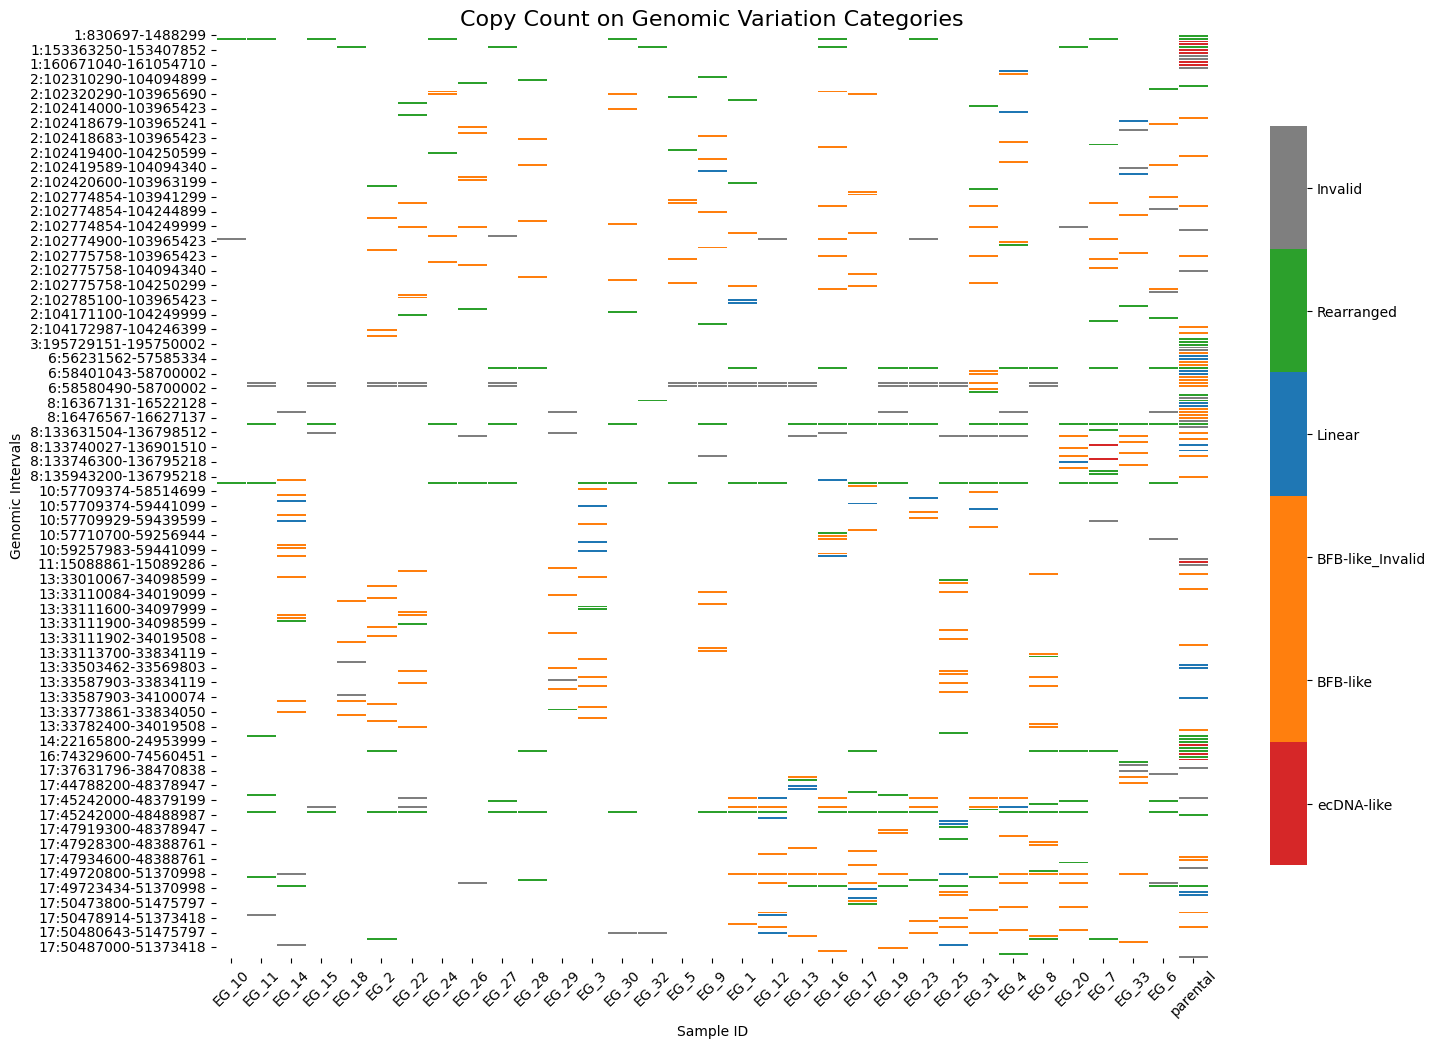

In [107]:
from matplotlib.colors import ListedColormap

df_exploded = df_exploded_all.copy()

df_exploded = df_exploded_all[df_exploded_all['Intervals_split'].isin(interval_list)]

# pivot 결과 cn_matrix, cat_matrix가 이미 만들어져 있다고 가정
cn_matrix_sorted = cn_matrix.reindex(index=interval_order)
cat_matrix_sorted = cat_matrix.reindex(index=interval_order)

# heatmap에 넣을 row subset이 interval_list라면, 그 subset도 genomic order로 정렬:
interval_list_sorted = [x for x in interval_order if x in set(interval_list)]

cn_matrix_filtered = cn_matrix_sorted.loc[interval_list_sorted]
cat_matrix_filtered = cat_matrix_sorted.loc[interval_list_sorted]

# heatmap에 넣을 row subset이 interval_list라면, 그 subset도 genomic order로 정렬:
interval_list_sorted = [x for x in interval_order if x in set(interval_list)]

cn_matrix_filtered = cn_matrix_sorted.loc[interval_list_sorted]
cat_matrix_filtered = cat_matrix_sorted.loc[interval_list_sorted]



# 2. 카테고리(문자열)를 숫자로 매핑 (컬러맵 적용용)
category_labels = list(color_map2.keys())
category_to_int = {label: i for i, label in enumerate(category_labels)}
int_to_color = [color_map2[label] for label in category_labels]

# 히트맵 배경용 숫자 행렬
cat_numeric = cat_matrix_filtered.replace(category_to_int)

# 3. 히트맵 그리기
plt.figure(figsize=(16, 12))  # 숫자가 잘 보이도록 사이즈를 넉넉히 조절

custom_cmap = ListedColormap(int_to_color)

# annot=cn_matrix_filtered: 실제 Copy Count 숫자를 셀에 표시
# fmt=".1f": 소수점 첫째자리까지 표시 (정수라면 "d"로 변경)
ax = sns.heatmap(
    cat_numeric, 
#     annot=cn_matrix_filtered, 
#     fmt=".1f", 
    cmap=custom_cmap, 
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.8}
)

# 4. 컬러바 범례 설정 (오른쪽 바에 카테고리명 표시)
colorbar = ax.collections[0].colorbar
num_labels = len(category_labels)
r = colorbar.vmax - colorbar.vmin
colorbar.set_ticks([colorbar.vmin + r / num_labels * (i + 0.5) for i in range(num_labels)])
colorbar.set_ticklabels(category_labels)

plt.title("Copy Count on Genomic Variation Categories", fontsize=16)
plt.ylabel("Genomic Intervals")
plt.xlabel("Sample ID")
plt.xticks(rotation=45)
plt.show()

In [108]:
# interval_list로 필터된 df_exploded를 이미 만들었다고 가정
# df_exploded = df_exploded_all[df_exploded_all['Intervals_split'].isin(interval_list)]

cn_mat = df_exploded.pivot_table(
    index="Intervals_split",
    columns="sample_id",
    values="Copy_count",
    aggfunc="max"
)

# 원하는 interval만/원하는 순서로
cn_mat = cn_mat.loc[interval_list]

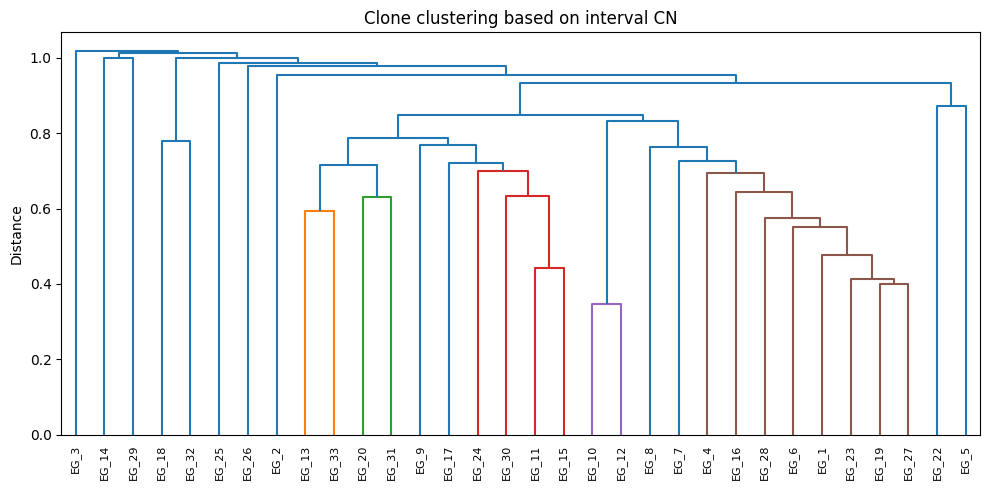

In [109]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt



X = cn_mat.copy()

# 결측은 0으로 (없으면 0 copy로 취급)
X = X.fillna(0)

# parental 제외
cols = X.columns.tolist()
has_parental = "parental" in cols
clone_cols = [c for c in cols if c != "parental"]

X_clone = X[clone_cols].T  # rows=sample, cols=interval feature

# 추천: correlation (패턴 유사성)
dist = pdist(X_clone, metric="correlation")
Z = linkage(dist, method="average")

plt.figure(figsize=(10, 5))
dendrogram(Z, labels=X_clone.index, leaf_rotation=90)
plt.title("Clone clustering based on interval CN")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

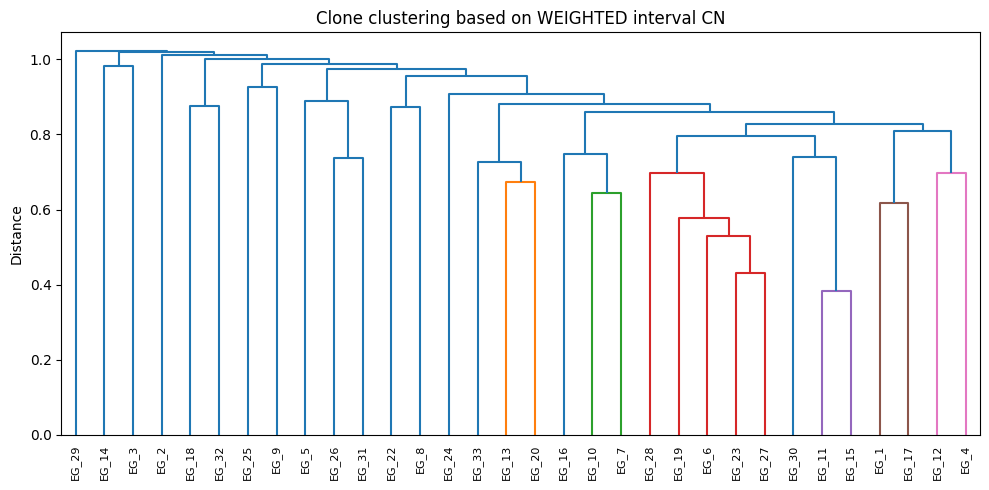

In [110]:
class_weight = {
    "ecDNA-like": 5,
    "BFB-like": 4,
    "BFB-like_Invalid": 3,
    "Linear": 2,
    "Rearranged": 1,
    "Invalid": 0   # Invalid는 아예 영향 없게(원하면 1로)
}
cn = cn_mat.fillna(0)

cat = cat_matrix.copy()

w_mat = cat.applymap(lambda x: class_weight.get(x, 1))  # 모르는 class는 weight=1 기본
cn_weighted = cn * w_mat


from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

X = cn_weighted.fillna(0)

has_parental = "parental" in X.columns
clone_cols = [c for c in X.columns if c != "parental"]

X_clone = X[clone_cols].T  # rows=sample, cols=interval feature

# correlation(패턴 중심) 추천
dist = pdist(X_clone, metric="correlation")
Z = linkage(dist, method="average")

plt.figure(figsize=(10, 5))
dendrogram(Z, labels=X_clone.index, leaf_rotation=90)
plt.title("Clone clustering based on WEIGHTED interval CN")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [111]:
k = 5
labels = fcluster(Z, t=k, criterion="maxclust")
cluster_df_interval = pd.DataFrame({
    "sample_id": X_clone.index,
    "cluster_group": labels
}).sort_values(["cluster_group", "sample_id"])

cluster_df_interval

,sample_id,cluster_group
5,EG_14,1
21,EG_3,1
9,EG_18,2
24,EG_32,2
0,EG_1,3
1,EG_10,3
2,EG_11,3
3,EG_12,3
4,EG_13,3
6,EG_15,3


In [112]:
ordered_samples = cluster_df_interval["sample_id"].tolist()

if has_parental:
    ordered_samples = ordered_samples + ["parental"]

In [113]:
# 기존처럼 다시 만드셔도 되고, 이미 만든 cn_mat/cat_matrix를 재사용해도 됩니다.
cn_matrix = df_exploded.pivot_table(
    index="Intervals_split",
    columns="sample_id",
    values="Copy_count",
    aggfunc="max"
).loc[interval_list, ordered_samples]

cat_matrix = df_exploded.pivot_table(
    index="Intervals_split",
    columns="sample_id",
    values="CycleClass",
    aggfunc=lambda x: x.iloc[0]
).loc[interval_list, ordered_samples]

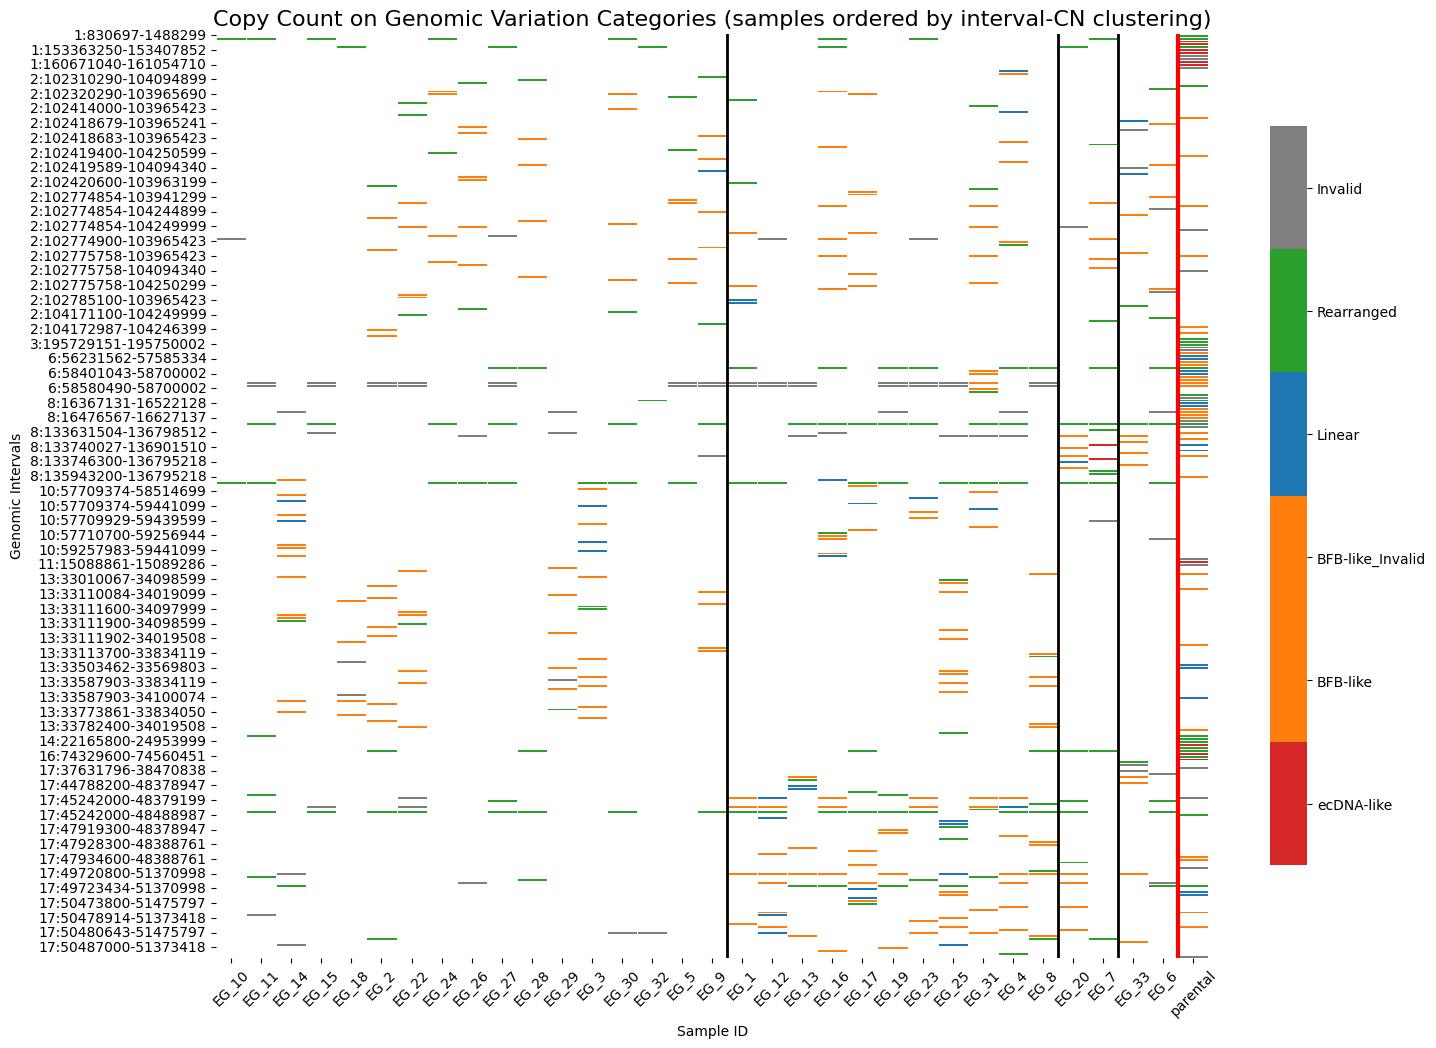

In [114]:
# 2. 카테고리(문자열)를 숫자로 매핑 (컬러맵 적용용)
category_labels = list(color_map2.keys())
category_to_int = {label: i for i, label in enumerate(category_labels)}
int_to_color = [color_map2[label] for label in category_labels]

# 히트맵 배경용 숫자 행렬
cat_numeric = cat_matrix_filtered.replace(category_to_int)

# 3. 히트맵 그리기
plt.figure(figsize=(16, 12))
custom_cmap = ListedColormap(int_to_color)

ax = sns.heatmap(
    cat_numeric,
    # annot=cn_matrix_filtered,   # 원하면 다시 켜세요
    # fmt=".1f",
    cmap=custom_cmap,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8}
)

# 4. 컬러바 범례 설정 (오른쪽 바에 카테고리명 표시)
colorbar = ax.collections[0].colorbar
num_labels = len(category_labels)
r = colorbar.vmax - colorbar.vmin
colorbar.set_ticks([colorbar.vmin + r / num_labels * (i + 0.5) for i in range(num_labels)])
colorbar.set_ticklabels(category_labels)

# ✅ cluster boundary 선
for b in boundaries:
    ax.axvline(b, color="black", linewidth=2)

# ✅ parental 맨 오른쪽 강조선 (있을 때만)
if "parental" in ordered_samples:
    parental_pos = ordered_samples.index("parental")
    ax.axvline(parental_pos, color="red", linewidth=3)

plt.title("Copy Count on Genomic Variation Categories (samples ordered by interval-CN clustering)", fontsize=16)
plt.ylabel("Genomic Intervals")
plt.xlabel("Sample ID")
plt.xticks(rotation=45)
plt.show()

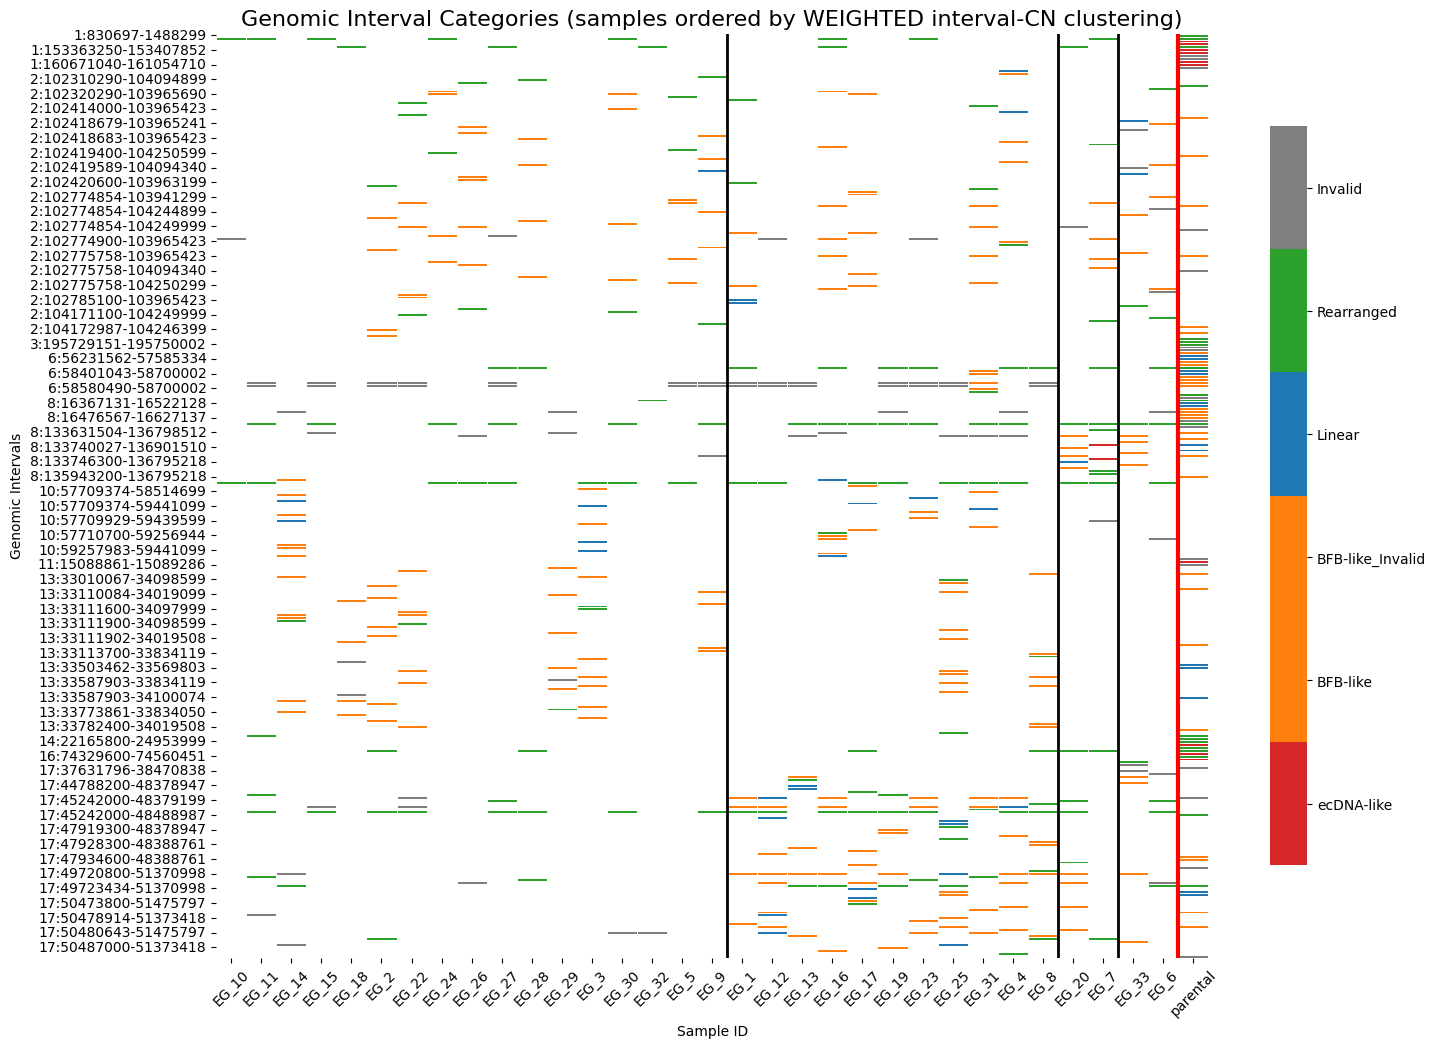

In [115]:
from matplotlib.colors import ListedColormap
import seaborn as sns
import matplotlib.pyplot as plt

# 2. 카테고리(문자열)를 숫자로 매핑 (컬러맵 적용용)
category_labels = list(color_map2.keys())
category_to_int = {label: i for i, label in enumerate(category_labels)}
int_to_color = [color_map2[label] for label in category_labels]

# 히트맵 배경용 숫자 행렬
cat_numeric = cat_matrix_filtered.replace(category_to_int)

# 3. 히트맵 그리기
plt.figure(figsize=(16, 12))
custom_cmap = ListedColormap(int_to_color)

ax = sns.heatmap(
    cat_numeric,
    # ✅ 숫자 표시를 원하면 아래 둘 중 하나 선택
    # annot=cn_matrix_filtered,    # raw Copy_count 표시
    # annot=cn_weighted,           # weighted Copy_count 표시
    # fmt=".1f",
    cmap=custom_cmap,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8}
)

# 4. 컬러바 범례 설정
colorbar = ax.collections[0].colorbar
num_labels = len(category_labels)
r = colorbar.vmax - colorbar.vmin
colorbar.set_ticks([colorbar.vmin + r / num_labels * (i + 0.5) for i in range(num_labels)])
colorbar.set_ticklabels(category_labels)

# ✅ cluster boundary 선
for b in boundaries:
    ax.axvline(b, color="black", linewidth=2)

# ✅ parental 맨 오른쪽 강조선
if "parental" in ordered_samples:
    parental_pos = ordered_samples.index("parental")
    ax.axvline(parental_pos, color="red", linewidth=3)

plt.title("Genomic Interval Categories (samples ordered by WEIGHTED interval-CN clustering)", fontsize=16)
plt.ylabel("Genomic Intervals")
plt.xlabel("Sample ID")
plt.xticks(rotation=45)
plt.show()

In [168]:
path='/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/results/aaSuite_feature_similarity/v1.3.8/GRCh37/minCN4.5/cnsizeMin50000/10X/ecDNA/aaSuite_feature_similarity/ECTRES-EFM19-0001/run_similarity'
similarity=pd.read_csv(f'{path}/ECTRES-EFM19-0001_feature_similarity_scores.tsv',sep='\t')
print(similarity.shape)

similarity.head()



(98, 19)


,Amp1,Amp2,SimilarityScore,SimScorePercentile,SimScorePvalue,AsymmetricScore1,AsymmetricScore2,GenomicSegmentScore1,GenomicSegmentScore2,BreakpointScore1,BreakpointScore2,JaccardGenomicSegment,JaccardBreakpoint,NumSharedBPs,Amp1NumBPs,Amp2NumBPs,AmpOverlapLen,Amp1AmpLen,Amp2AmpLen
0,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2...,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2...,1.000,100.0,0.000000e+00,1.0,1.00,1.0,1.0,1.0,1.000000,1.0,1.000000,3.0,3,3,489323,489323,489323
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon2...,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS_amplicon2...,1.000,100.0,0.000000e+00,1.0,1.00,1.0,1.0,1.0,1.000000,1.0,1.000000,1.0,1,1,481213,481213,481213
2,ECTRES-EFM19-0001-TPX-A06-WGS-JLY9G1_amplicon2...,ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34_amplicon8...,1.000,100.0,0.000000e+00,1.0,1.00,1.0,1.0,1.0,1.000000,1.0,1.000000,1.0,1,1,61494,61494,61494
3,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY_amplicon2...,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2...,0.875,100.0,5.056982e-07,1.0,0.75,1.0,1.0,1.0,0.666667,1.0,0.666667,2.0,2,3,489323,489323,489323
4,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY_amplicon2...,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2...,0.875,100.0,5.056982e-07,1.0,0.75,1.0,1.0,1.0,0.666667,1.0,0.666667,2.0,2,3,489323,489323,489323
